In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import pyleoclim as pyleo

In [2]:
## load data
data = pd.read_csv('data.csv')
data.head()

,time_s_,x1,x2
0,0.000,-0.1,0.1
1,0.001,-0.1,0.1
2,0.002,-0.1,0.1
3,0.003,-0.1,0.1
4,0.004,-0.1,0.1


In [3]:
ts_x1=pyleo.Series(time=data['time_s_'], value=data['x1'], value_name='x1', time_name='time', value_unit='units', time_unit='s')
ts_x2=pyleo.Series(time=data['time_s_'], value=data['x2'], value_name='x2', time_name='time', value_unit='units', time_unit='s')

Time axis values sorted in ascending order
Time axis values sorted in ascending order


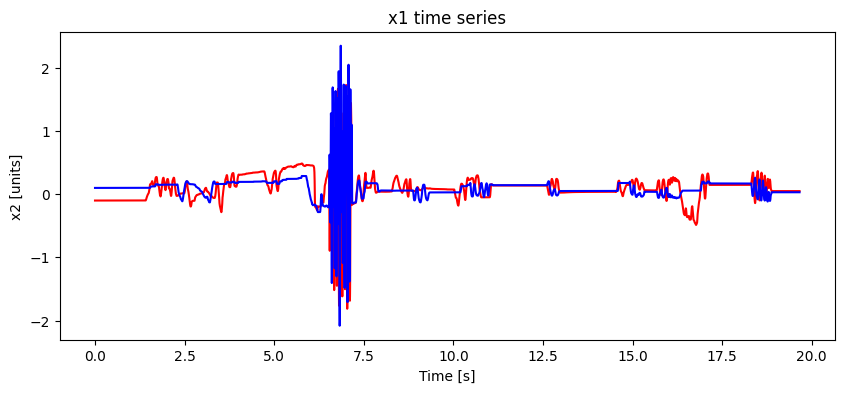

In [54]:
# plot the series
fig, ax = ts_x1.plot(title='x1 time series', color='red')
ts_x2.plot(ax=ax, color='blue')
plt.show()

## Standardize

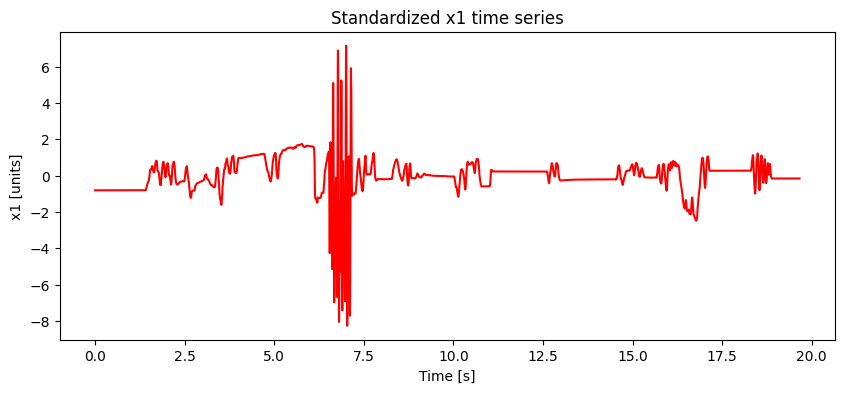

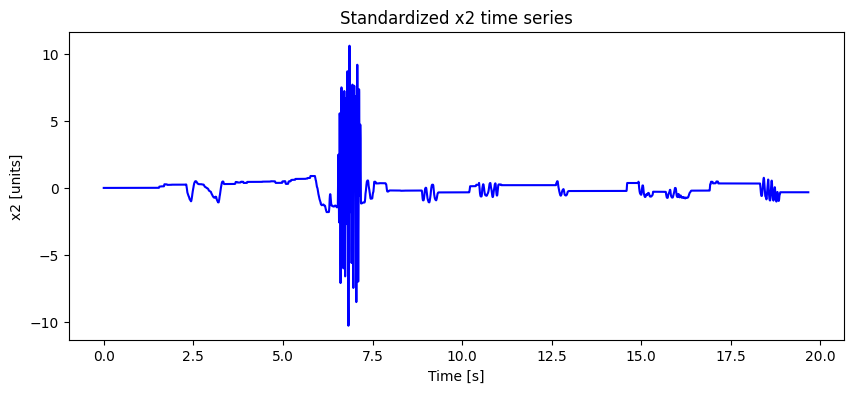

In [5]:
ts_x1_std = ts_x1.standardize()
ts_x2_std = ts_x2.standardize()

fig, ax = ts_x1_std.plot(title='Standardized x1 time series', color='red')
plt.show()
fig, ax = ts_x2_std.plot(title='Standardized x2 time series', color='blue')
plt.show()

## Window Function

In [6]:
# compute windows
window_size = 1 # seconds
overlap = window_size 

# 2 s window array example
# [0, 1], [1, 2], [2, 3], [3, 4], [4, 5]
windows = [ [x , x + window_size] for x in range(0, 10, window_size) ]

def window_fn(ts, window_size, start_time=0, final_time=10):
    assert window_size > 0, "Window size must be positive"
    assert final_time > start_time, "Final time must be greater than start time"
    assert (final_time - start_time) >= window_size, "Time range must be at least as large as window size"
    assert type(window_size) == int, "Window size must be an integer"
    
    windows = [ [x , x + window_size] for x in range(start_time, final_time, window_size) ]
    return [ts.slice(x) for x in windows]

# slice ts_x1
ts_x1_windowed = window_fn(ts_x1, window_size, start_time=0, final_time=10)
ts_x2_windowed = window_fn(ts_x2, window_size, start_time=0, final_time=10)

#ts_x1.slice([0, 5])
# ts_x2_windowed = ts_x2_std.window(size=window_size, overlap=0.5)

## Earth Mover Distance (EMD)


In [7]:
from scipy.stats import wasserstein_distance

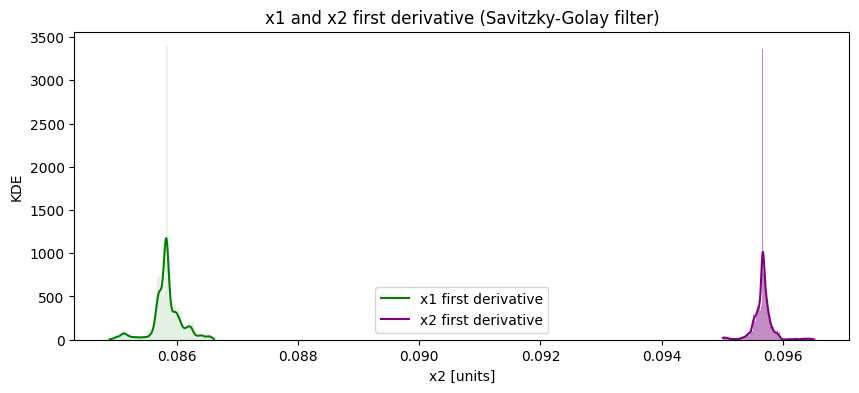

In [8]:
fig, ax = ts_x1.filter(method='savitzky-golay', cutoff_freq=1.0, deriv=1).histplot(title='x1 and x2 first derivative (Savitzky-Golay filter)', color='green')
ts_x2.filter(method='savitzky-golay', cutoff_freq=1.0, deriv=1).histplot(color='purple', ax=ax)
plt.legend(['x1 first derivative', 'x2 first derivative'])
plt.show()

In [9]:
# calculate velocities
v1 = ts_x1.filter(method='savitzky-golay', cutoff_freq=1.0, deriv=1)
v2 = ts_x2.filter(method='savitzky-golay', cutoff_freq=1.0, deriv=1)

# calculate Earth Mover's Distance between velocity distributions
emd = wasserstein_distance(v1.value, v2.value)
print("Earth Mover's Distance between velocity distributions: {:.4f}".format(emd))

Earth Mover's Distance between velocity distributions: 0.0098


In [ ]:
# apply wasserstein_distance on each window
emd_windows = []
for w1, w2 in zip(ts_x1_windowed, ts_x2_windowed):
    v1_w = w1.filter(method='savitzky-golay', cutoff_freq=1.0, deriv=1)
    v2_w = w2.filter(method='savitzky-golay', cutoff_freq=1.0, deriv=1)
    emd_w = wasserstein_distance(v1_w.value, v2_w.value)
    emd_windows.append([v1_w.time[-1], emd_w])

print("Earth Mover's Distance for each window:")
emd_windows


Earth Mover's Distance for each window:


[[1.0, 0.20000000000000004],
 [2.0, 0.09078292944354577],
 [3.0, 0.07932465636993344],
 [4.0, 0.032730527390353044],
 [5.0, 0.09521390521996395],
 [6.0, 0.18183404184519908],
 [7.0, 0.13426747941345815],
 [8.0, 0.07340993594363333],
 [9.0, 0.05043880442939797],
 [10.0, 0.0659379871603383]]

Time axis values sorted in ascending order


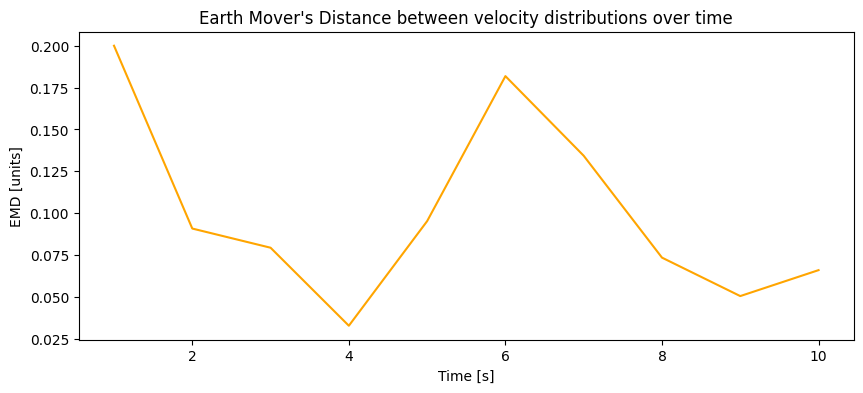

In [55]:
# create a Series for emd_windows
emd_series = pyleo.Series(time=[x[0] for x in emd_windows], value=[x[1] for x in emd_windows], time_name='time', value_name='EMD', time_unit='s', value_unit='units')
fig, ax = emd_series.plot(title='Earth Mover\'s Distance between velocity distributions over time', color='orange')
plt.show()

## Granger Causality Test

In [11]:
ts_x1.causality(ts_x2, method='granger')


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=231.7655, p=0.0000  , df_denom=19658, df_num=1
ssr based chi2 test:   chi2=231.8009, p=0.0000  , df=1
likelihood ratio test: chi2=230.4451, p=0.0000  , df=1
parameter F test:         F=231.7655, p=0.0000  , df_denom=19658, df_num=1


{1: ({'ssr_ftest': (231.76552739061, 4.8665516782737545e-52, 19658.0, 1),
   'ssr_chi2test': (231.80089704073572, 2.413256503877369e-52, 1),
   'lrtest': (230.4450903982215, 4.767340713499207e-52, 1),
   'params_ftest': (231.76552738928416, 4.866551681468294e-52, 19658.0, 1.0)},
   array([[0., 1., 0.]])])}

## Phase

In [36]:
def circular_mean(rad_array):
    # returns mean angle in radians
    return np.angle(np.mean(np.exp(1j * rad_array)))

phase_windows = []
for w1, w2 in zip(ts_x1_windowed, ts_x2_windowed):
    coh = w1.wavelet_coherence(w2)
    phases = coh.phase  # shape (n_scales, n_times)
    final_phases = phases[:, -1]  # phases at the final time column
    phase_angle_deg = np.degrees(circular_mean(final_phases)) # mean phase angle in degrees
    phase_windows.append([w1.time[-1], phase_angle_deg])


Time axis values sorted in ascending order


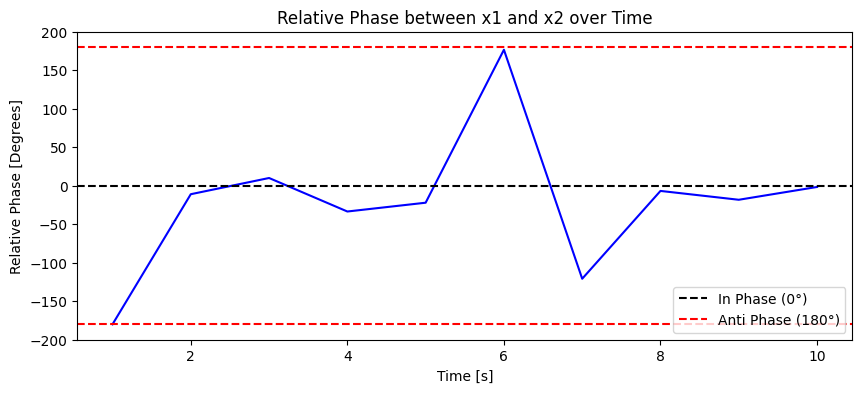

In [53]:
# create series of phase over time
phase_series_arr = np.array(phase_windows)
phase_series = pyleo.Series(time=phase_series_arr[:,0], value=phase_series_arr[:,1], value_name='Relative Phase', time_name='Window', value_unit='Degrees', time_unit='s')

# plot phase over time
fig, ax = phase_series.plot(title='Relative Phase between x1 and x2 over Time', color='blue')
plt.axhline(0, color='black', linestyle='--', label='In Phase (0°)')
plt.axhline(180, color='red', linestyle='--', label='Anti Phase (180°)')
plt.axhline(-180, color='red', linestyle='--')
plt.ylim([-200, 200])
plt.legend(loc='lower right')
plt.show()

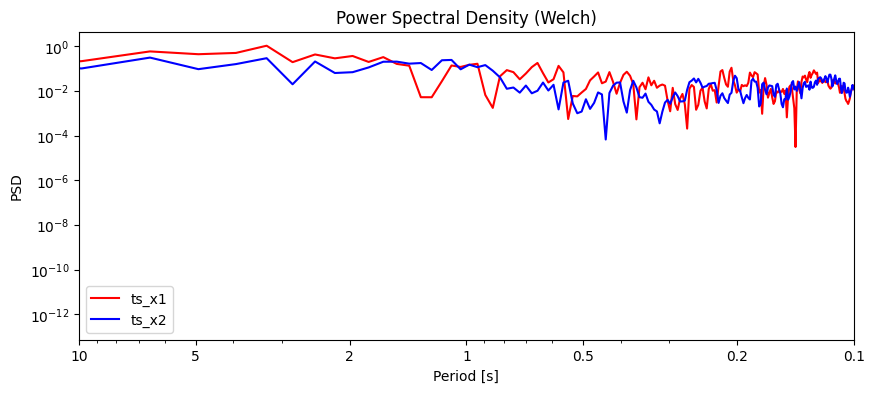

In [19]:
PSD_p = ts_x1.standardize().interp().spectral(method='welch')
fig, ax = PSD_p.plot(label = 'ts_x1', title='Power Spectral Density (Welch)', color='red')
PSD_p2 = ts_x2.standardize().interp().spectral(method='welch')
PSD_p2.plot(label = 'ts_x2', color='blue', ax=ax)
plt.legend()
plt.show()

In [4]:
data['x1_viz'] = data[['x1', 'x2']].apply(lambda row: row['x1'] if row['x1'] < row['x2'] else (row['x2'] + row['x1'])/2, axis=1)
data['x2_viz'] = data[['x1', 'x2']].apply(lambda row: row['x2'] if row['x2'] > row['x1'] else (row['x2'] + row['x1'])/2, axis=1)